In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # image related ops
import numpy as np
import cv2 # opencv lib

In [9]:
img_path = "./car1.jpeg"

In [10]:
car1 = mpimg.imread(img_path)

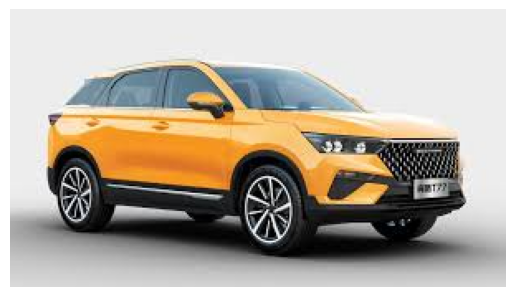

In [50]:

# car1
plt.imshow(car1)
plt.axis('off')
plt.show()

In [26]:
car1.shape

(168, 300, 3)

In [29]:
car1_cv2 = cv2.imread(img_path)

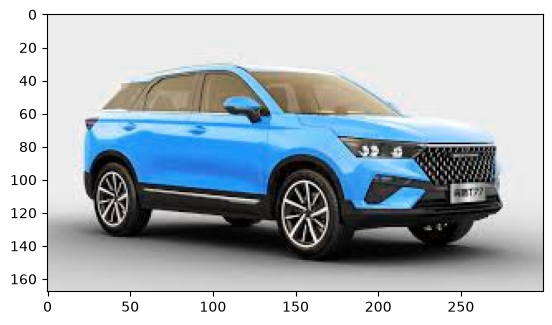

In [33]:
plt.imshow(car1_cv2)

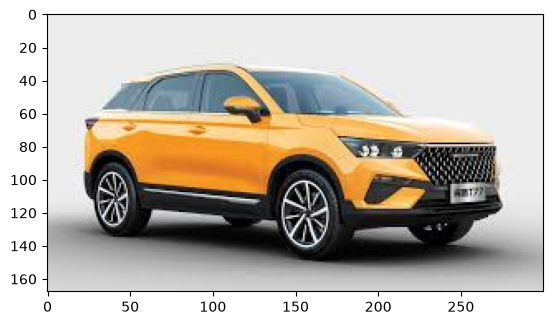

In [32]:
car1_cv2_BGR_RGB = cv2.cvtColor(car1_cv2, cv2.COLOR_BGR2RGB)
plt.imshow(car1_cv2_BGR_RGB)

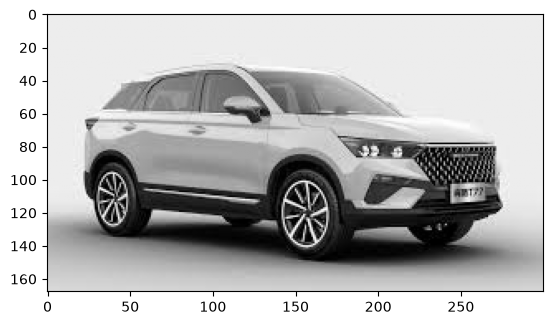

In [42]:
car1_cv2_BGR_GRAY = cv2.cvtColor(car1_cv2, cv2.COLOR_BGR2GRAY)
plt.imshow(car1_cv2_BGR_GRAY, cmap="gray")

In [45]:
car1_cv2_BGR_GRAY.shape

(168, 300)

In [46]:
car1_cv2_BGR_GRAY.min()

np.uint8(0)

In [48]:
car1_cv2_BGR_GRAY.max()

np.uint8(255)

In [51]:
def viusalize_RGB_channel(imgArray=None, figsize=(10,7)):
  # splitting the RGB components
  B, G, R = cv2.split(imgArray)

  # create zero matrix of shape of image
  Z = np.zeros(B.shape, dtype=B.dtype) # can use any channel

  # init subplots
  fig, ax = plt.subplots(2,2, figsize=figsize)

  # plotting the actual image and RGB images
  [axi.set_axis_off() for axi in ax.ravel()]

  ax[0,0].set_title("Original Image")
  # ax[0,0].set_axis_off()
  ax[0,0].imshow(cv2.merge((R,G,B)))

  ax[0,1].set_title("Red Ch Image")
  ax[0,1].imshow(cv2.merge((R,Z,Z)))

  ax[1,0].set_title("Green Ch Image")
  ax[1,0].imshow(cv2.merge((Z,G,Z)))

  ax[1,1].set_title("Blue Ch Image")
  ax[1,1].imshow(cv2.merge((Z,Z,B)))

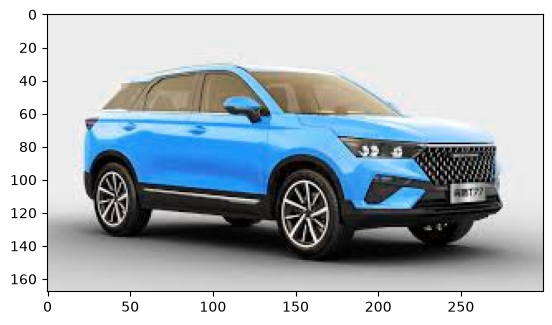

In [57]:
plt.imshow(car1_cv2)

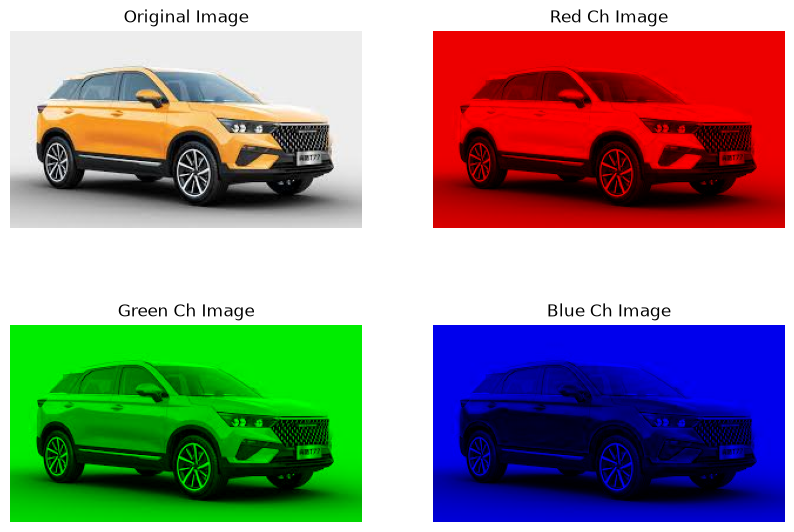

In [58]:
viusalize_RGB_channel(imgArray= car1_cv2)

In [59]:
random_colored_img =np.random.randint(0, 255, (6,6,3))
random_colored_img.shape

(6, 6, 3)

In [61]:
random_colored_img

array([[[214,  29,  60],
        [153, 226, 226],
        [ 11, 164, 112],
        [ 57, 120,  62],
        [ 57,  80,  46],
        [ 52, 163, 232]],

       [[ 31, 250, 136],
        [ 41,  32,  61],
        [124, 246, 244],
        [ 67, 186,  73],
        [201, 186, 216],
        [112, 195, 227]],

       [[173, 130,  56],
        [145,  66, 215],
        [113, 131,  37],
        [ 92,  87, 144],
        [119, 195, 249],
        [111,  81,  89]],

       [[145, 127,  11],
        [ 42, 128, 153],
        [  0, 224,  96],
        [ 66,   4,  87],
        [ 69,  54,  20],
        [156,   6, 215]],

       [[242,  84,  31],
        [242, 169, 175],
        [120, 111,  95],
        [ 52,  25,  56],
        [ 32,  30,  51],
        [235,  51, 139]],

       [[101, 142, 251],
        [101, 213, 212],
        [194,  36, 101],
        [ 57,  59,  24],
        [107, 120, 124],
        [  9, 252, 190]]], dtype=int32)

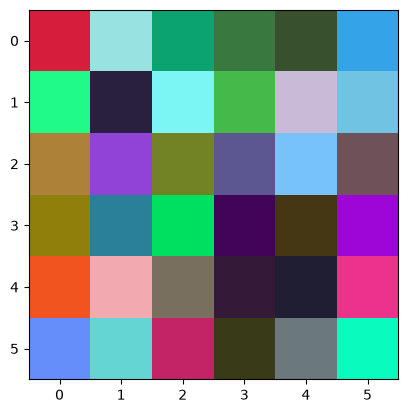

In [62]:
plt.imshow(random_colored_img)

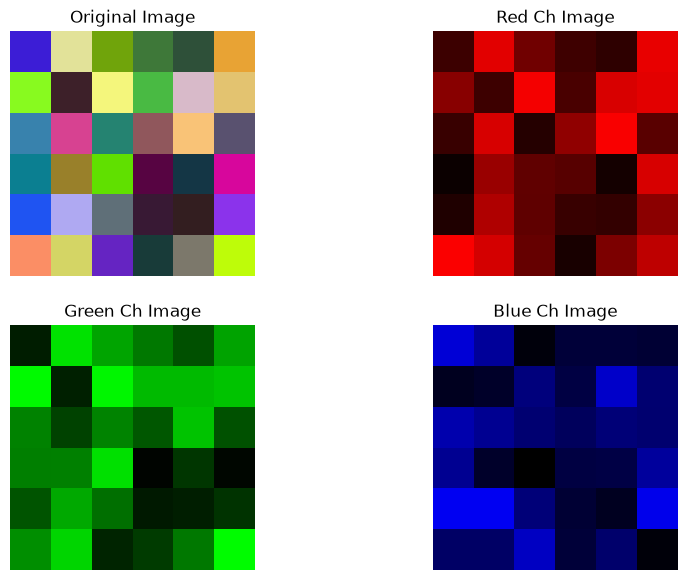

In [65]:
viusalize_RGB_channel(imgArray= random_colored_img)

# Understanding filters

In [80]:
sobel = np.array([[1,0,-1],
                  [2,0,-1],
                  [1,0,-1]])
print("highlighting Vertical edges:\n", sobel)


highlighting Vertical edges:
 [[ 1  0 -1]
 [ 2  0 -1]
 [ 1  0 -1]]


In [81]:
print("highlighting Vertical edges:\n", sobel.T)

highlighting Vertical edges:
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -1 -1]]


In [83]:

example1 = [
    [0,0,0,0,255,255,255,255,0,0,0,0],
    [0,0,0,0,255,255,255,255,0,0,0,0],
    [0,0,0,0,255,255,255,255,0,0,0,0],
    [0,0,0,0,255,255,255,255,0,0,0,0],
    [0,0,0,0,255,255,255,255,255,255,255,255],
    [0,0,0,0,255,255,255,255,255,255,255,255],
    [0,0,0,0,255,255,255,255,255,255,255,255],
    [0,0,0,0,255,255,255,255,255,255,255,255],
    [0,0,0,0,255,255,255,255,0,0,0,0],
    [0,0,0,0,255,255,255,255,0,0,0,0],
    [0,0,0,0,255,255,255,255,0,0,0,0],
    [0,0,0,0,255,255,255,255,0,0,0,0],
            ]

example1 = np.array(example1)

In [69]:
example1

array([[  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255, 255, 255, 255],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255, 255, 255, 255],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255, 255, 255, 255],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255, 255, 255, 255],
       [  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0]])

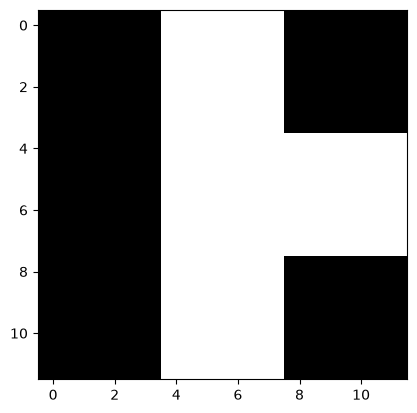

In [84]:
plt.imshow(example1, cmap="gray")

In [85]:
def simple_conv(imgFilter=None, picture=None):
  # extract the shape of the image
  p_row, p_col = picture.shape

  k = imgFilter.shape[0] # k =3

  temp = list()

  stride = 1

  # resulant image size
  final_cols = (p_col - k)//stride + 1
  final_rows = (p_row - k)//stride + 1

  # take vertically down stride across row by row
  for v_stride in range(final_rows):
    # take horizontal right stride across col by col
    for h_stride in range(final_cols):
      target_area_of_pic = picture[v_stride: v_stride + k, h_stride: h_stride + k]
      z = sum(sum(imgFilter * target_area_of_pic))
      temp.append(z)

  resulant_image = np.array(temp).reshape(final_rows, final_cols)
  return resulant_image
     

In [86]:
results = simple_conv(imgFilter=sobal, picture=example1)

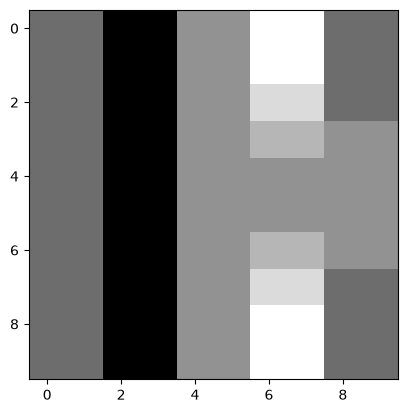

In [87]:
plt.imshow(results, cmap="gray")

In [88]:
results = simple_conv(imgFilter=sobal.T, picture=example1)

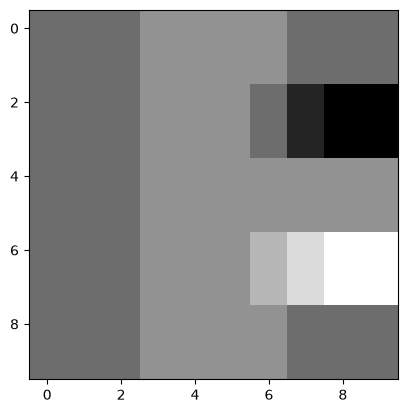

In [89]:
plt.imshow(results, cmap="gray")

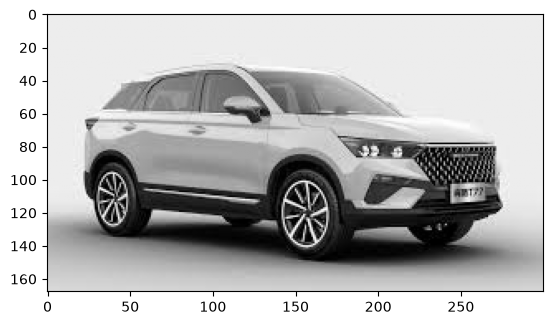

In [90]:
car1_cv2_BGR_GRAY = cv2.cvtColor(car1_cv2, cv2.COLOR_BGR2GRAY)
plt.imshow(car1_cv2_BGR_GRAY, cmap="gray")

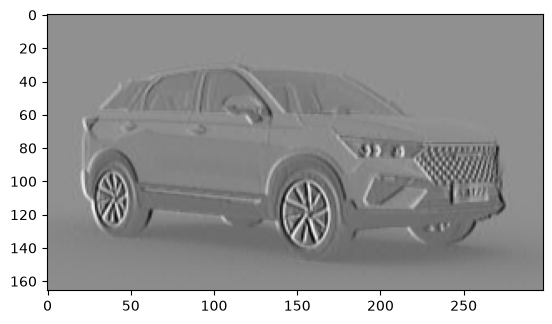

In [91]:
results = simple_conv(imgFilter=sobal, picture=car1_cv2_BGR_GRAY)
plt.imshow(results, cmap="gray")

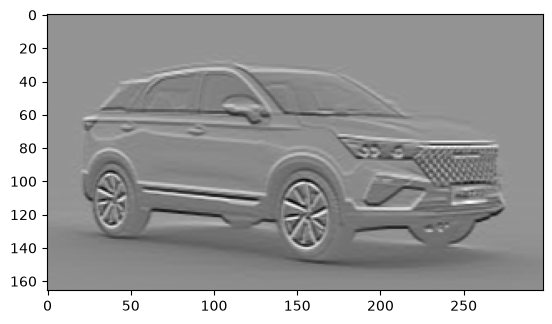

In [92]:
results = simple_conv(imgFilter=sobal.T, picture=car1_cv2_BGR_GRAY)
plt.imshow(results, cmap="gray")